# Schémas illustratifs EWC — pour présentation

Quatre schémas "faciles à comprendre" mais fidèles au projet **CL-Embedded** :

1. **EWC sur PC** — fonctionnement (entraînement continu + régularisation Fisher)
2. **EWC sur board NUCLEO-F439ZI** — entraînement / inférence / update
3. **Ingestion des données — Pronostia** (D4, 13 features)
4. **Ingestion des données — Monitoring** (D2, 4 features)

Les figures sont exportées en PNG dans `docs/figures/ewc_illustrations/` pour la présentation.

Références projet : `configs/ewc_config.yaml` (Monitoring), `configs/pronostia_config.yaml`, `firmware/stm32f4_blink/src/ewc_head.c`.

In [1]:
import os
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch, Circle
from matplotlib.lines import Line2D

OUTDIR = os.path.join('..', '..', '..', 'docs', 'figures', 'ewc_illustrations')
os.makedirs(OUTDIR, exist_ok=True)

# Palette projet
C_DATA   = '#dbeafe'  # bleu clair — données
C_MODEL  = '#bfdbfe'  # bleu — modèle
C_EWC    = '#fde68a'  # ambre — mécanisme EWC / Fisher
C_OUT    = '#bbf7d0'  # vert — sortie / prédiction
C_UPDATE = '#fecaca'  # rouge clair — update / backprop
C_BOARD  = '#e9d5ff'  # violet — board
EDGE = '#334155'

plt.rcParams.update({'font.size': 11, 'font.family': 'DejaVu Sans'})


def box(ax, xy, w, h, text, color=C_MODEL, fs=11, ec=EDGE, lw=1.5, bold=False, txtcol='#0f172a'):
    x, y = xy
    p = FancyBboxPatch((x, y), w, h, boxstyle='round,pad=0.02,rounding_size=0.08',
                       fc=color, ec=ec, lw=lw, zorder=2)
    ax.add_patch(p)
    ax.text(x + w / 2, y + h / 2, text, ha='center', va='center', fontsize=fs,
            zorder=3, fontweight='bold' if bold else 'normal', color=txtcol, wrap=True)
    return (x + w / 2, y + h / 2)


def arrow(ax, p0, p1, text='', color=EDGE, fs=9.5, style='-|>', lw=1.8, rad=0.0,
          ls='-', toff=(0, 0.12)):
    a = FancyArrowPatch(p0, p1, arrowstyle=style, mutation_scale=16, color=color,
                        lw=lw, ls=ls, connectionstyle=f'arc3,rad={rad}', zorder=1)
    ax.add_patch(a)
    if text:
        mx, my = (p0[0] + p1[0]) / 2 + toff[0], (p0[1] + p1[1]) / 2 + toff[1]
        ax.text(mx, my, text, ha='center', va='center', fontsize=fs, color=color,
                style='italic', zorder=4,
                bbox=dict(boxstyle='round,pad=0.15', fc='white', ec='none', alpha=0.85))


def setup(ax, xlim, ylim, title):
    ax.set_xlim(*xlim); ax.set_ylim(*ylim); ax.axis('off')
    ax.set_title(title, fontsize=15, fontweight='bold', pad=14, color='#0f172a')

print('Helpers prêts. Sortie ->', os.path.abspath(OUTDIR))

Helpers prêts. Sortie -> /home/leonard/Documents/ENAC/cl-embedded/docs/figures/ewc_illustrations


## 1. EWC sur PC — fonctionnement

Apprentissage continu sur une suite de tâches. À chaque nouvelle tâche, EWC **protège** les poids importants des tâches passées via la **matrice de Fisher** (online, décroissance γ=0.9), en ajoutant un terme de régularisation à la loss (λ=1000).

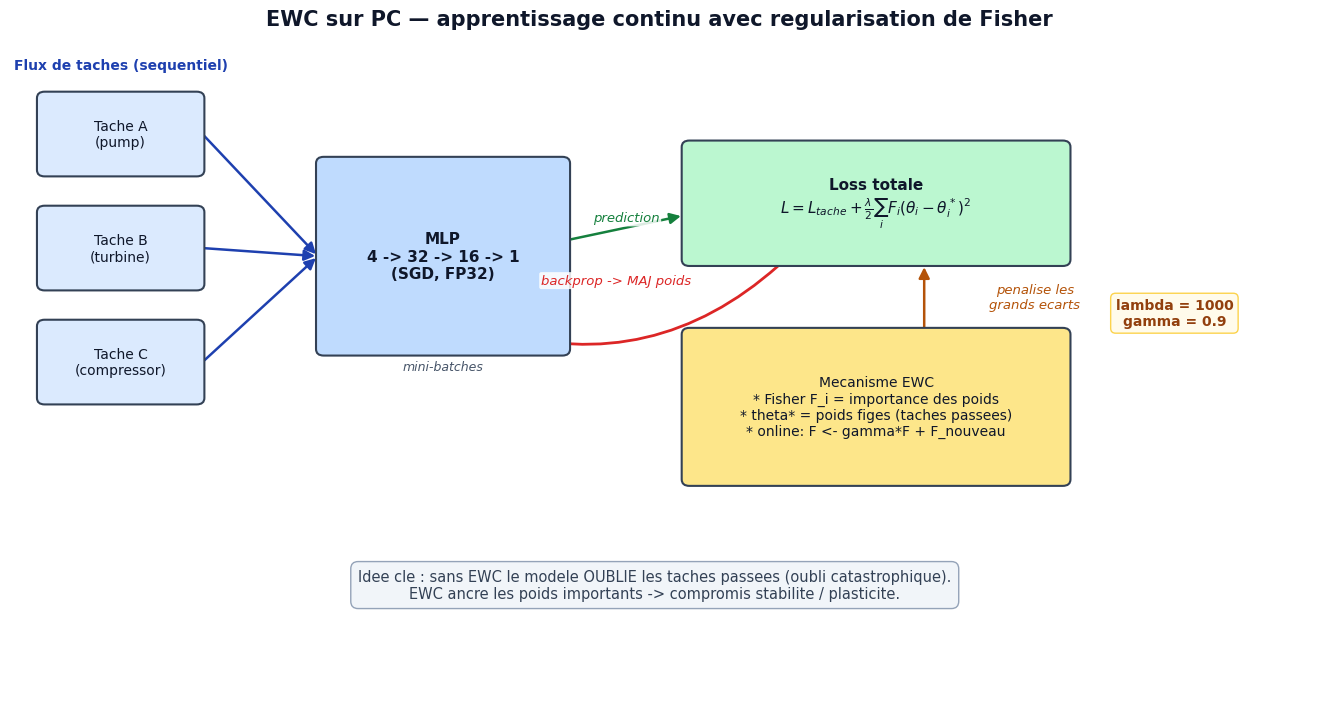

In [2]:
fig, ax = plt.subplots(figsize=(13.5, 7.2))
setup(ax, (0, 13.5), (0, 8), 'EWC sur PC — apprentissage continu avec regularisation de Fisher')

# Suite de tâches
box(ax, (0.3, 6.4), 1.7, 1.0, 'Tache A\n(pump)', C_DATA, fs=10)
box(ax, (0.3, 5.0), 1.7, 1.0, 'Tache B\n(turbine)', C_DATA, fs=10)
box(ax, (0.3, 3.6), 1.7, 1.0, 'Tache C\n(compressor)', C_DATA, fs=10)
ax.text(1.15, 7.7, 'Flux de taches (sequentiel)', ha='center', fontsize=10, fontweight='bold', color='#1e40af')

# MLP
mlp = box(ax, (3.2, 4.2), 2.6, 2.4, 'MLP\n4 -> 32 -> 16 -> 1\n(SGD, FP32)', C_MODEL, fs=11, bold=True)
for p in [(2.0, 6.9), (2.0, 5.5), (2.0, 4.1)]:
    arrow(ax, p, (3.2, 5.4), color='#1e40af', toff=(0, 0))
ax.text(4.5, 4.0, 'mini-batches', ha='center', fontsize=9, style='italic', color='#475569')

# Loss
loss = box(ax, (7.0, 5.3), 4.0, 1.5,
           r'Loss totale' + '\n' + r'$L = L_{tache} + \frac{\lambda}{2}\sum_i F_i(\theta_i-\theta_i^*)^2$',
           C_OUT, fs=11, bold=True)
arrow(ax, (5.8, 5.6), (7.0, 5.9), 'prediction', color='#15803d')

# EWC / Fisher
fisher = box(ax, (7.0, 2.6), 4.0, 1.9,
             'Mecanisme EWC\n* Fisher F_i = importance des poids\n* theta* = poids figes (taches passees)\n* online: F <- gamma*F + F_nouveau',
             C_EWC, fs=10, bold=False)
arrow(ax, (9.5, 4.5), (9.5, 5.3), 'penalise les\ngrands ecarts', color='#b45309', rad=0.0, toff=(1.15, 0))

# Hyperparamètres EWC — bande libre à droite
ax.text(12.1, 4.7, 'lambda = 1000\ngamma = 0.9', ha='center', va='center', fontsize=10,
        fontweight='bold', color='#92400e',
        bbox=dict(boxstyle='round,pad=0.35', fc='#fffbeb', ec='#fcd34d'))

# Backprop -> update poids
arrow(ax, (8.0, 5.3), (5.0, 4.5), 'backprop -> MAJ poids', color='#dc2626', rad=-0.28, lw=2.0, toff=(-0.2, 0.2))

# Note bas
ax.text(6.7, 1.2, 'Idee cle : sans EWC le modele OUBLIE les taches passees (oubli catastrophique).\n'
                  'EWC ancre les poids importants -> compromis stabilite / plasticite.',
        ha='center', fontsize=10.5, color='#334155',
        bbox=dict(boxstyle='round,pad=0.5', fc='#f1f5f9', ec='#94a3b8'))

plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, '1_ewc_pc.png'), dpi=160, bbox_inches='tight')
plt.show()

## 2. EWC sur board NUCLEO-F439ZI — entraînement / inférence / update

Le même MLP tourne **en C sur le Cortex-M4** (FP32, pas de NPU). Trois modes distincts, chiffres mesurés au DWT (Sprints 26/36) :
- **Inférence seule** : forward pass — ~48–65 µs
- **Inférence + update (online CL)** : forward + backprop + consolidation Fisher — ~239–340 µs
- Les deux **≪ 100 ms** (Gap 2 ✅).

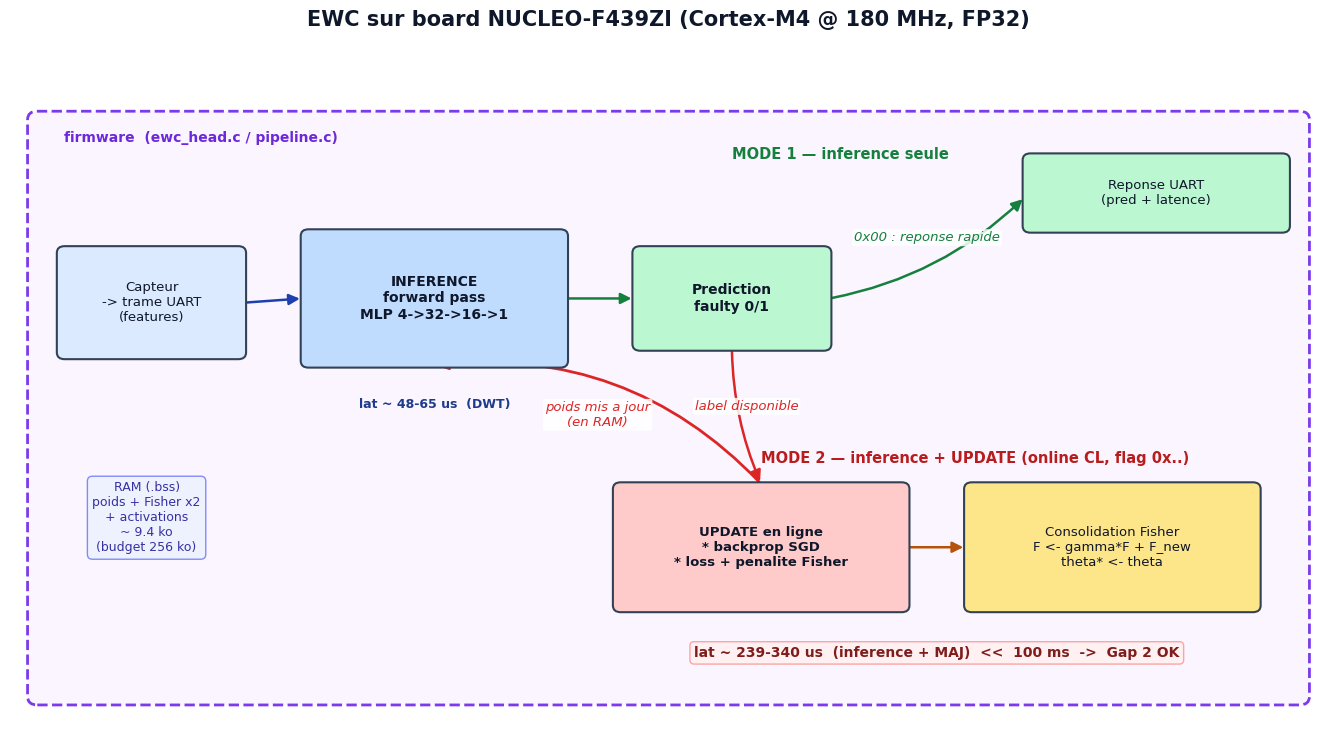

In [3]:
fig, ax = plt.subplots(figsize=(13.5, 7.6))
setup(ax, (0, 13.5), (0, 8.2), 'EWC sur board NUCLEO-F439ZI (Cortex-M4 @ 180 MHz, FP32)')

# Bandeau board
board = FancyBboxPatch((0.2, 0.4), 13.1, 7.0, boxstyle='round,pad=0.02,rounding_size=0.1',
                       fc='#faf5ff', ec='#7c3aed', lw=2, ls='--', zorder=0)
ax.add_patch(board)
ax.text(0.55, 7.05, 'firmware  (ewc_head.c / pipeline.c)', fontsize=10, color='#6d28d9', fontweight='bold')

# Capteur / UART
box(ax, (0.5, 4.5), 1.9, 1.3, 'Capteur\n-> trame UART\n(features)', C_DATA, fs=9.5)

# Forward (commun)
fwd = box(ax, (3.0, 4.4), 2.7, 1.6, 'INFERENCE\nforward pass\nMLP 4->32->16->1', C_MODEL, fs=10, bold=True)
arrow(ax, (2.4, 5.15), (3.0, 5.2), '', color='#1e40af')
pred = box(ax, (6.4, 4.6), 2.0, 1.2, 'Prediction\nfaulty 0/1', C_OUT, fs=10, bold=True)
arrow(ax, (5.7, 5.2), (6.4, 5.2), '', color='#15803d')
ax.text(4.35, 3.9, 'lat ~ 48-65 us  (DWT)', ha='center', fontsize=9, color='#1e3a8a', fontweight='bold')

# Mode 1 : inference seule
ax.text(7.4, 6.85, 'MODE 1 — inference seule', fontsize=10.5, fontweight='bold', color='#15803d')
arrow(ax, (8.4, 5.2), (10.4, 6.4), '0x00 : reponse rapide', color='#15803d', rad=0.15)
box(ax, (10.4, 6.0), 2.7, 0.9, 'Reponse UART\n(pred + latence)', C_OUT, fs=9.5)

# Mode 2 : inference + update
ax.text(7.7, 3.25, 'MODE 2 — inference + UPDATE (online CL, flag 0x..)', fontsize=10.5,
        fontweight='bold', color='#b91c1c')
upd = box(ax, (6.2, 1.5), 3.0, 1.5, 'UPDATE en ligne\n* backprop SGD\n* loss + penalite Fisher', C_UPDATE, fs=9.5, bold=True)
arrow(ax, (7.4, 4.6), (7.7, 3.0), 'label disponible', color='#dc2626', rad=0.1)
fish = box(ax, (9.8, 1.5), 3.0, 1.5, 'Consolidation Fisher\nF <- gamma*F + F_new\ntheta* <- theta', C_EWC, fs=9.5)
arrow(ax, (9.2, 2.25), (9.8, 2.25), '', color='#b45309')
arrow(ax, (7.7, 3.0), (4.35, 4.4), 'poids mis a jour\n(en RAM)', color='#dc2626', rad=0.25, lw=2.0)
ax.text(9.5, 0.95, 'lat ~ 239-340 us  (inference + MAJ)  <<  100 ms  ->  Gap 2 OK', ha='center',
        fontsize=10, color='#7f1d1d', fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.3', fc='#fff1f2', ec='#fca5a5'))

# Encadre memoire
ax.text(1.4, 2.6, 'RAM (.bss)\npoids + Fisher x2\n+ activations\n~ 9.4 ko\n(budget 256 ko)',
        ha='center', va='center', fontsize=9, color='#3730a3',
        bbox=dict(boxstyle='round,pad=0.4', fc='#eef2ff', ec='#818cf8'))

plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, '2_ewc_board.png'), dpi=160, bbox_inches='tight')
plt.show()

## 3. Ingestion des données — Pronostia (D4)

Roulements FEMTO, accéléromètres @ 25.6 kHz. Le signal brut est **fenêtré** (2560 points = 0.1 s, sans recouvrement), puis on extrait **6 statistiques × 2 canaux + position temporelle = 13 features**. Label : les derniers 10 % du signal = pré-défaillance (`faulty=1`). Scénario **class-incremental par condition opératoire** (3 tâches).

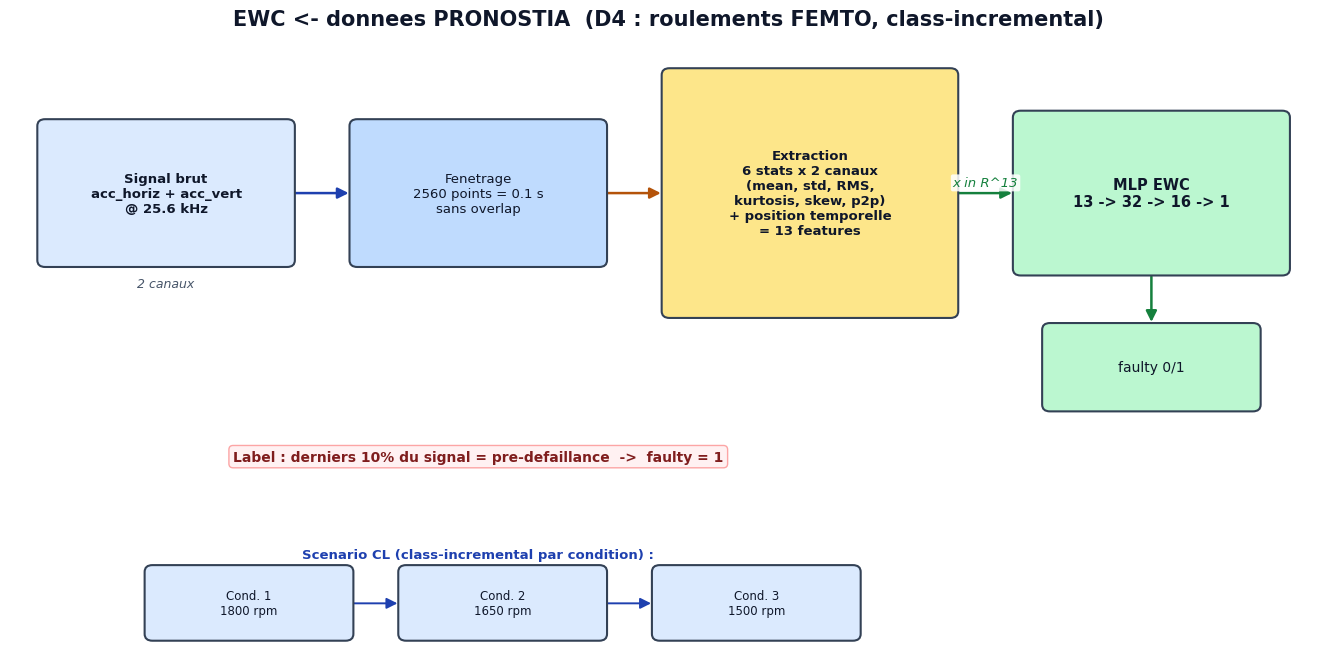

In [4]:
fig, ax = plt.subplots(figsize=(13.5, 6.8))
setup(ax, (0, 13.5), (0, 7.2), 'EWC <- donnees PRONOSTIA  (D4 : roulements FEMTO, class-incremental)')

# Signal brut
box(ax, (0.3, 4.6), 2.6, 1.7, 'Signal brut\nacc_horiz + acc_vert\n@ 25.6 kHz', C_DATA, fs=9.5, bold=True)
ax.text(1.6, 4.35, '2 canaux', ha='center', fontsize=9, style='italic', color='#475569')

# Fenetrage
win = box(ax, (3.5, 4.6), 2.6, 1.7, 'Fenetrage\n2560 points = 0.1 s\nsans overlap', C_MODEL, fs=9.5)
arrow(ax, (2.9, 5.45), (3.5, 5.45), '', color='#1e40af')

# Extraction features
feat = box(ax, (6.7, 4.0), 3.0, 2.9,
           'Extraction\n6 stats x 2 canaux\n(mean, std, RMS,\nkurtosis, skew, p2p)\n+ position temporelle\n= 13 features',
           C_EWC, fs=9.5, bold=True)
arrow(ax, (6.1, 5.45), (6.7, 5.45), '', color='#b45309')

# Vecteur features -> MLP
mlp = box(ax, (10.3, 4.5), 2.8, 1.9, 'MLP EWC\n13 -> 32 -> 16 -> 1', C_OUT, fs=10.5, bold=True)
arrow(ax, (9.7, 5.45), (10.3, 5.45), 'x in R^13', color='#15803d')
box(ax, (10.6, 2.9), 2.2, 1.0, 'faulty 0/1', C_OUT, fs=10)
arrow(ax, (11.7, 4.5), (11.7, 3.9), '', color='#15803d')

# Label
ax.text(4.8, 2.3, 'Label : derniers 10% du signal = pre-defaillance  ->  faulty = 1', ha='center',
        fontsize=10, color='#7f1d1d', fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.3', fc='#fff1f2', ec='#fca5a5'))

# Taches CL
ax.text(4.8, 1.15, 'Scenario CL (class-incremental par condition) :', ha='center', fontsize=9.5, fontweight='bold', color='#1e40af')
for i, (lab, x) in enumerate([('Cond. 1\n1800 rpm', 1.4), ('Cond. 2\n1650 rpm', 4.0), ('Cond. 3\n1500 rpm', 6.6)]):
    box(ax, (x, 0.2), 2.1, 0.85, lab, C_DATA, fs=8.5)
    if i < 2:
        arrow(ax, (x + 2.1, 0.62), (x + 2.6, 0.62), '', color='#1e40af', lw=1.4)

plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, '3_ewc_pronostia.png'), dpi=160, bbox_inches='tight')
plt.show()

## 4. Ingestion des données — Monitoring (D2)

Equipment Monitoring : données **tabulaires statiques**, pas de fenêtrage. 4 features numériques (température, pression, vibration, humidité), normalisées (z-score), label `faulty`. Scénario **domain-incremental par type d'équipement** (pump → turbine → compressor).

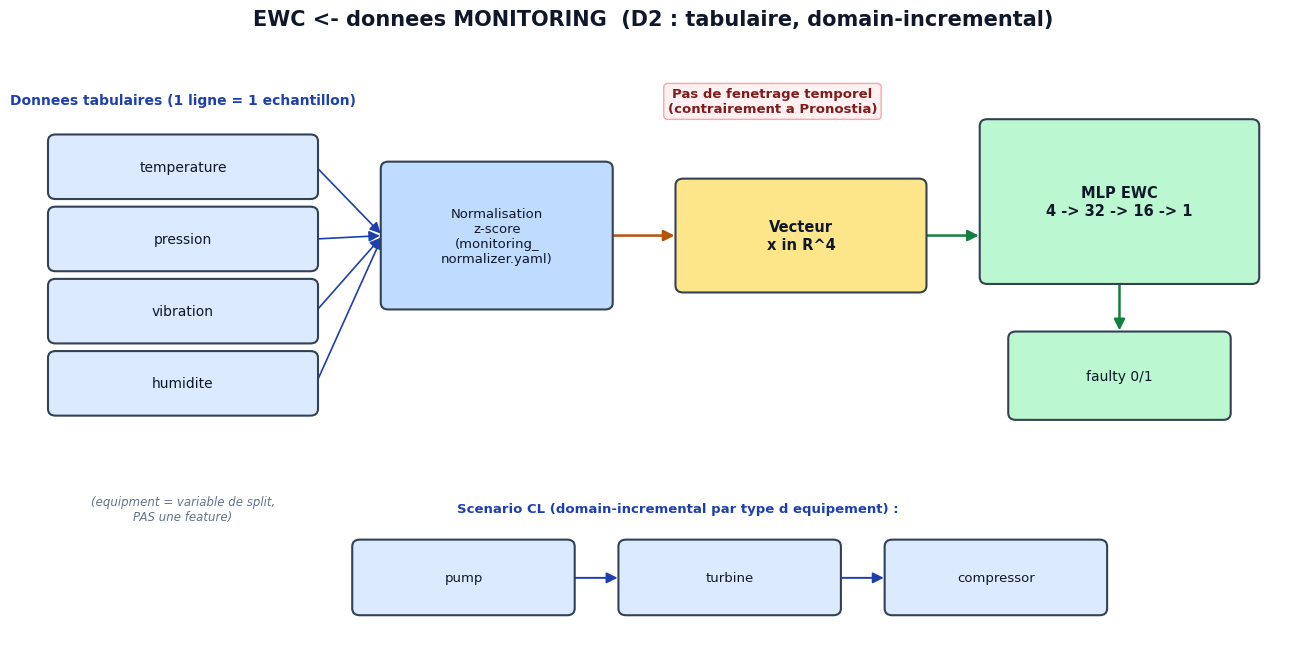

In [5]:
fig, ax = plt.subplots(figsize=(13.5, 6.8))
setup(ax, (0, 13.5), (0, 7.2), 'EWC <- donnees MONITORING  (D2 : tabulaire, domain-incremental)')

# Lignes tabulaires
feats = ['temperature', 'pression', 'vibration', 'humidite']
ax.text(1.8, 6.5, 'Donnees tabulaires (1 ligne = 1 echantillon)', ha='center', fontsize=10, fontweight='bold', color='#1e40af')
for i, f in enumerate(feats):
    box(ax, (0.4, 5.4 - i * 0.85), 2.8, 0.72, f, C_DATA, fs=10)
ax.text(1.8, 1.6, '(equipment = variable de split,\nPAS une feature)', ha='center', fontsize=8.5,
        style='italic', color='#64748b')

# Normalisation
box(ax, (3.9, 4.1), 2.4, 1.7, 'Normalisation\nz-score\n(monitoring_\nnormalizer.yaml)', C_MODEL, fs=9.5)
for i in range(4):
    arrow(ax, (3.2, 5.76 - i * 0.85), (3.9, 4.95), '', color='#1e40af', lw=1.2)

# Vecteur 4 features
box(ax, (7.0, 4.3), 2.6, 1.3, 'Vecteur\nx in R^4', C_EWC, fs=10.5, bold=True)
arrow(ax, (6.3, 4.95), (7.0, 4.95), '', color='#b45309')

# MLP
box(ax, (10.2, 4.4), 2.9, 1.9, 'MLP EWC\n4 -> 32 -> 16 -> 1', C_OUT, fs=10.5, bold=True)
arrow(ax, (9.6, 4.95), (10.2, 4.95), '', color='#15803d')
box(ax, (10.5, 2.8), 2.3, 1.0, 'faulty 0/1', C_OUT, fs=10)
arrow(ax, (11.65, 4.4), (11.65, 3.8), '', color='#15803d')

# Note pas de fenetrage
ax.text(8.0, 6.4, 'Pas de fenetrage temporel\n(contrairement a Pronostia)', ha='center', fontsize=9.5,
        color='#7f1d1d', fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.3', fc='#fff1f2', ec='#fca5a5'))

# Taches CL domain-incremental
ax.text(7.0, 1.7, 'Scenario CL (domain-incremental par type d equipement) :', ha='center',
        fontsize=9.5, fontweight='bold', color='#1e40af')
for i, (lab, x) in enumerate([('pump', 3.6), ('turbine', 6.4), ('compressor', 9.2)]):
    box(ax, (x, 0.5), 2.3, 0.85, lab, C_DATA, fs=9.5)
    if i < 2:
        arrow(ax, (x + 2.3, 0.92), (x + 2.8, 0.92), '', color='#1e40af', lw=1.4)

plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, '4_ewc_monitoring.png'), dpi=160, bbox_inches='tight')
plt.show()

---
### Figures exportées

| Fichier | Contenu |
|---|---|
| `1_ewc_pc.png` | EWC sur PC — régularisation Fisher |
| `2_ewc_board.png` | EWC sur board — inférence / update |
| `3_ewc_pronostia.png` | Ingestion Pronostia (13 features, fenêtrage) |
| `4_ewc_monitoring.png` | Ingestion Monitoring (4 features, tabulaire) |

Dans `docs/figures/ewc_illustrations/`.